# 05 - Analyze Model Results

Reusable analysis notebook for model training and prediction outputs.

This notebook defaults to the current CT mosaic classifier results in `outputs/resnet18_head_chest/`, but it is intentionally model-agnostic: update `RESULTS_DIR` at the top to analyze a future model run, architecture, or expanded class set.

## 1. Setup and Configurable Paths

Change `RESULTS_DIR` to point at another model run. The notebook expects the same artifact names produced by the training script: `test_metrics.json`, `test_predictions.csv`, `splits.csv`, `history.csv`, and optionally `label_mapping.json`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

RESULTS_DIR = REPO_ROOT / "outputs" / "resnet18_head_chest"
MANIFEST_CSV = REPO_ROOT / "outputs" / "mosaic_manifest.csv"
METRICS_JSON = RESULTS_DIR / "test_metrics.json"
PREDICTIONS_CSV = RESULTS_DIR / "test_predictions.csv"
SPLITS_CSV = RESULTS_DIR / "splits.csv"
HISTORY_CSV = RESULTS_DIR / "history.csv"
LABEL_MAPPING_JSON = RESULTS_DIR / "label_mapping.json"

REQUIRED_FILES = [
    MANIFEST_CSV,
    METRICS_JSON,
    PREDICTIONS_CSV,
    SPLITS_CSV,
    HISTORY_CSV,
]

missing = [path for path in REQUIRED_FILES if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required result file(s):\n" + "\n".join(map(str, missing)))

print("repo root   :", REPO_ROOT)
print("results dir :", RESULTS_DIR)
print("manifest    :", MANIFEST_CSV)

repo root   : /Users/lucaspu/HelperV1
results dir : /Users/lucaspu/HelperV1/outputs/resnet18_head_chest
manifest    : /Users/lucaspu/HelperV1/outputs/mosaic_manifest.csv


## 2. Load Results

This section loads all model outputs and infers the class names dynamically. It avoids hardcoding the current `head`/`chest` labels so the notebook can still work for future multi-class models.

In [2]:
def resolve_repo_path(value: str | Path) -> Path:
    path = Path(value)
    if not path.is_absolute():
        path = REPO_ROOT / path
    return path


def load_label_mapping() -> tuple[dict[str, int], dict[int, str]]:
    if not LABEL_MAPPING_JSON.exists():
        return {}, {}
    label_to_index = json.loads(LABEL_MAPPING_JSON.read_text())
    index_to_label = {int(index): label for label, index in label_to_index.items()}
    return label_to_index, index_to_label


def map_label_value(value, index_to_label: dict[int, str]) -> str:
    if pd.isna(value):
        return "unknown"
    try:
        numeric_value = int(value)
    except (TypeError, ValueError):
        return str(value)
    return index_to_label.get(numeric_value, str(value))


def add_prediction_label_names(
    predictions: pd.DataFrame,
    index_to_label: dict[int, str],
) -> pd.DataFrame:
    predictions = predictions.copy()

    if "true_label_name" not in predictions.columns:
        if "true_label" in predictions.columns:
            predictions["true_label_name"] = predictions["true_label"].map(
                lambda value: map_label_value(value, index_to_label)
            )
        elif "body_region" in predictions.columns:
            predictions["true_label_name"] = predictions["body_region"].astype(str)
        else:
            raise KeyError(
                "Could not infer true labels. Expected one of: "
                "true_label_name, true_label, body_region."
            )

    if "predicted_label_name" not in predictions.columns:
        if "predicted_label" in predictions.columns:
            predictions["predicted_label_name"] = predictions["predicted_label"].map(
                lambda value: map_label_value(value, index_to_label)
            )
        elif "prediction" in predictions.columns:
            predictions["predicted_label_name"] = predictions["prediction"].map(
                lambda value: map_label_value(value, index_to_label)
            )
        else:
            raise KeyError(
                "Could not infer predicted labels. Expected one of: "
                "predicted_label_name, predicted_label, prediction."
            )

    return predictions


def infer_class_names(
    metrics: dict,
    predictions: pd.DataFrame,
    label_to_index: dict[str, int],
) -> list[str]:
    if label_to_index:
        return [label for label, _ in sorted(label_to_index.items(), key=lambda item: item[1])]

    report = metrics.get("classification_report", {})
    ignored = {"accuracy", "macro avg", "weighted avg", "micro avg"}
    labels = [label for label in report if label not in ignored]
    if labels:
        return labels

    values = pd.concat([
        predictions["true_label_name"],
        predictions["predicted_label_name"],
    ]).dropna()
    return sorted(values.unique().tolist())


metrics = json.loads(METRICS_JSON.read_text())
predictions = pd.read_csv(PREDICTIONS_CSV)
splits = pd.read_csv(SPLITS_CSV)
history = pd.read_csv(HISTORY_CSV)
manifest = pd.read_csv(MANIFEST_CSV)
label_to_index, index_to_label = load_label_mapping()
predictions = add_prediction_label_names(predictions, index_to_label)
class_names = infer_class_names(metrics, predictions, label_to_index)

for frame in (predictions, splits, manifest):
    if "mosaic_path" in frame.columns:
        frame["resolved_mosaic_path"] = frame["mosaic_path"].map(resolve_repo_path)

predictions["correct"] = predictions["true_label_name"] == predictions["predicted_label_name"]

print("classes:", class_names)
print("manifest rows:", len(manifest))
print("prediction rows:", len(predictions))
print("split rows:", len(splits))
display(predictions.head())

classes: ['head', 'chest']
manifest rows: 200
prediction rows: 30
split rows: 200


,SeriesInstanceUID,body_region,true_label_name,predicted_label_name,mosaic_path,resolved_mosaic_path,correct
0,2.16.840.1.114362.1.12177026.25874454649.63773...,head,head,head,data/mosaics/2.16.840.1.114362.1.12177026.2587...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
1,1.2.826.0.1.3680043.10.474.419639.749785053180...,chest,chest,chest,data/mosaics/1.2.826.0.1.3680043.10.474.419639...,/Users/lucaspu/HelperV1/data/mosaics/1.2.826.0...,True
2,2.16.840.1.114274.1818.49372790976230298438844...,head,head,head,data/mosaics/2.16.840.1.114274.1818.4937279097...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
3,1.2.826.0.1.3680043.10.474.419639.752252137584...,chest,chest,chest,data/mosaics/1.2.826.0.1.3680043.10.474.419639...,/Users/lucaspu/HelperV1/data/mosaics/1.2.826.0...,True
4,1.2.826.0.1.3680043.10.474.302028.2773343,chest,chest,chest,data/mosaics/1.2.826.0.1.3680043.10.474.302028...,/Users/lucaspu/HelperV1/data/mosaics/1.2.826.0...,True


## 3. Dataset and Split Summary

Review the full manifest label distribution and the train/validation/test split balance. For future experiments, this helps catch accidental class imbalance before interpreting metrics.

Manifest label counts


,label,n
0,chest,100
1,head,100


Split counts


,split,body_region,n
0,test,chest,15
1,test,head,15
2,train,chest,70
3,train,head,69
4,val,chest,15
5,val,head,16


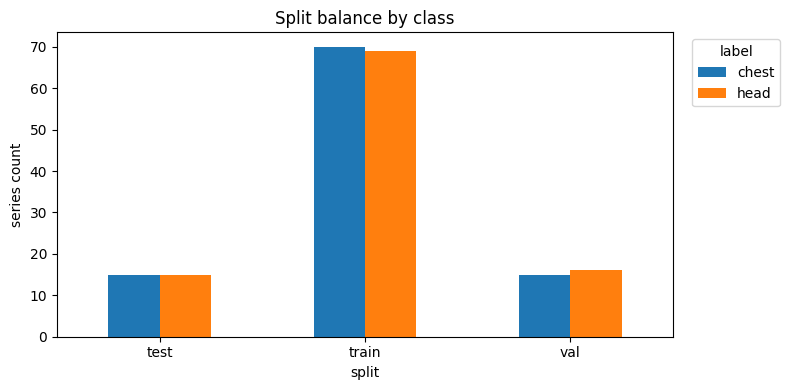

In [3]:
manifest_label_counts = manifest["body_region"].value_counts(dropna=False).rename_axis("label").reset_index(name="n")
split_counts = (
    splits.groupby(["split", "body_region"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["split", "body_region"])
)

print("Manifest label counts")
display(manifest_label_counts)
print("Split counts")
display(split_counts)

pivot = split_counts.pivot(index="split", columns="body_region", values="n").fillna(0)
ax = pivot.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Split balance by class")
ax.set_xlabel("split")
ax.set_ylabel("series count")
ax.legend(title="label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 4. Training Curves

Use the curves to check whether the model is still improving, overfitting, or already saturated.

,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy
0,1,0.237169,0.040475,1.0,1.0
1,2,0.008109,0.005645,1.0,1.0
2,3,0.012812,0.003250,1.0,1.0
3,4,0.004190,0.004811,1.0,1.0
4,5,0.001947,0.004178,1.0,1.0
5,6,0.004202,0.001945,1.0,1.0
6,7,0.000941,0.001368,1.0,1.0
7,8,0.001021,0.001476,1.0,1.0
8,9,0.001768,0.001462,1.0,1.0
9,10,0.000581,0.001424,1.0,1.0


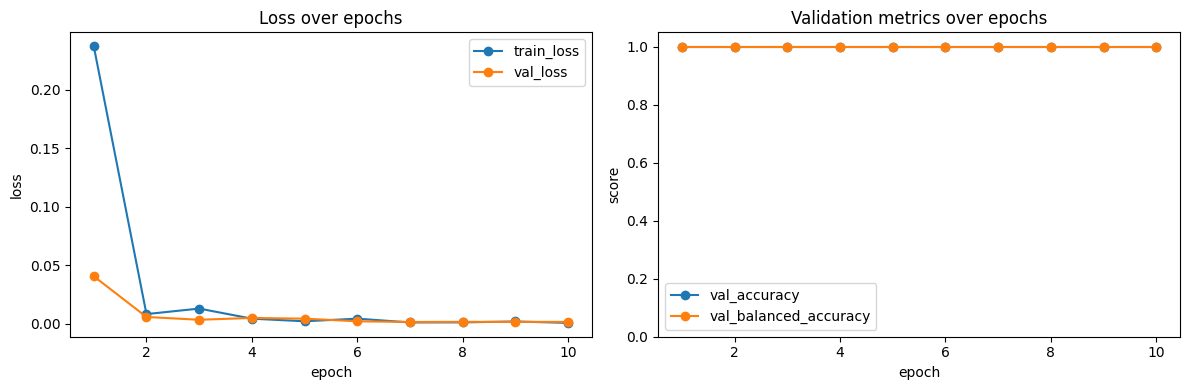

In [4]:
display(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train_loss")
if "val_loss" in history.columns:
    axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="val_loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

metric_cols = [col for col in ["val_accuracy", "val_balanced_accuracy"] if col in history.columns]
for col in metric_cols:
    axes[1].plot(history["epoch"], history[col], marker="o", label=col)
axes[1].set_title("Validation metrics over epochs")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("score")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()

## 5. Test Metrics

The classification report is generated dynamically from the metrics JSON, so it can handle more classes later.

In [5]:
print("loss:", metrics.get("loss"))
print("accuracy:", metrics.get("accuracy"))
print("balanced_accuracy:", metrics.get("balanced_accuracy"))

report = pd.DataFrame(metrics.get("classification_report", {})).T
if not report.empty:
    display(report)
else:
    print("No classification_report found in metrics JSON.")

loss: 0.04888731713096301
accuracy: 1.0
balanced_accuracy: 1.0


,precision,recall,f1-score,support
head,1.0,1.0,1.0,15.0
chest,1.0,1.0,1.0,15.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


## 6. Confusion Matrix

Shows raw counts and row-normalized percentages. Rows are true labels and columns are predicted labels.

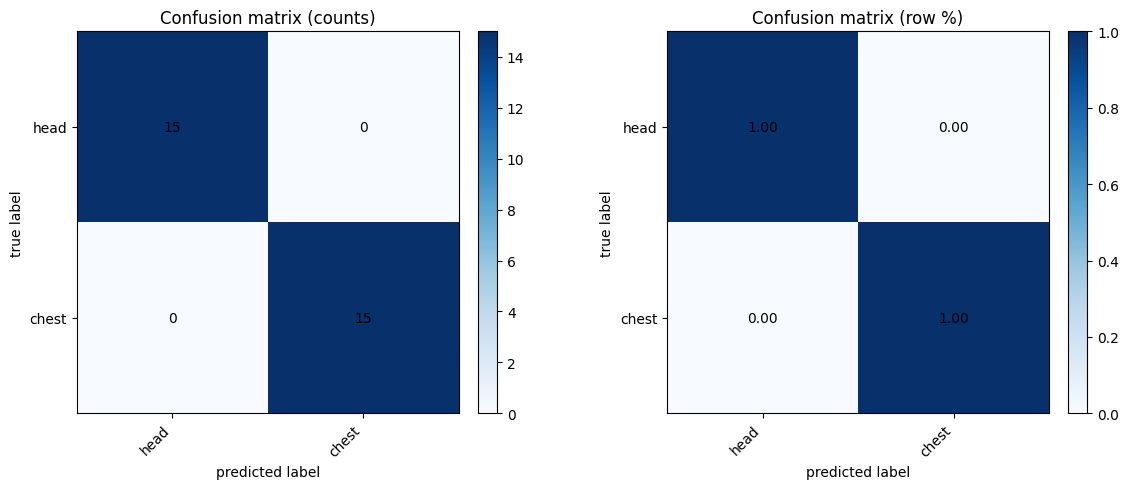

In [6]:
confusion = np.array(metrics.get("confusion_matrix", []))
if confusion.size == 0:
    print("No confusion_matrix found in metrics JSON.")
else:
    if confusion.shape[0] != len(class_names):
        class_names_for_plot = [str(i) for i in range(confusion.shape[0])]
    else:
        class_names_for_plot = class_names

    row_sums = confusion.sum(axis=1, keepdims=True)
    normalized = np.divide(confusion, row_sums, out=np.zeros_like(confusion, dtype=float), where=row_sums != 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, matrix, title, fmt in [
        (axes[0], confusion, "Confusion matrix (counts)", "d"),
        (axes[1], normalized, "Confusion matrix (row %)", ".2f"),
    ]:
        image = ax.imshow(matrix, cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("predicted label")
        ax.set_ylabel("true label")
        ax.set_xticks(range(len(class_names_for_plot)), class_names_for_plot, rotation=45, ha="right")
        ax.set_yticks(range(len(class_names_for_plot)), class_names_for_plot)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center")
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

## 7. Prediction Review

Misclassified examples are shown first. If there are no mistakes, inspect a balanced sample of correct predictions instead.

In [7]:
# Normalize label columns defensively in case this cell is rerun after loading
# a future predictions CSV with numeric labels only.
if "true_label_name" not in predictions.columns or "predicted_label_name" not in predictions.columns:
    if "index_to_label" not in globals():
        label_to_index = json.loads(LABEL_MAPPING_JSON.read_text()) if LABEL_MAPPING_JSON.exists() else {}
        index_to_label = {int(index): label for label, index in label_to_index.items()}
    predictions = add_prediction_label_names(predictions, index_to_label)

if "correct" not in predictions.columns:
    predictions["correct"] = predictions["true_label_name"] == predictions["predicted_label_name"]

label_col = "true_label_name"
accuracy_by_class = (
    predictions.groupby(label_col)["correct"]
    .agg(n="size", accuracy="mean")
    .reset_index()
    .sort_values(label_col)
)
display(accuracy_by_class)

mistakes = predictions[~predictions["correct"]].copy()
correct = predictions[predictions["correct"]].copy()

print(f"mistakes: {len(mistakes)} / {len(predictions)}")
if len(mistakes):
    display(mistakes)
else:
    sample = (
        correct.groupby(label_col, group_keys=False)
        .apply(lambda group: group.sample(min(len(group), 5), random_state=42))
        .reset_index(drop=True)
    )
    print("No mistakes in this run; showing a balanced sample of correct predictions.")
    display(sample)

,true_label_name,n,accuracy
0,chest,15,1.0
1,head,15,1.0


mistakes: 0 / 30
No mistakes in this run; showing a balanced sample of correct predictions.


,SeriesInstanceUID,body_region,predicted_label_name,mosaic_path,resolved_mosaic_path,correct
0,2.16.840.1.114274.1818.56720717027621131538448...,chest,chest,data/mosaics/2.16.840.1.114274.1818.5672071702...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
1,1.2.826.0.1.3680043.10.474.419639.205591984046...,chest,chest,data/mosaics/1.2.826.0.1.3680043.10.474.419639...,/Users/lucaspu/HelperV1/data/mosaics/1.2.826.0...,True
2,1.2.826.0.1.3680043.10.474.419639.749785053180...,chest,chest,data/mosaics/1.2.826.0.1.3680043.10.474.419639...,/Users/lucaspu/HelperV1/data/mosaics/1.2.826.0...,True
3,1.3.6.1.4.1.5962.99.1.3492129840.282517718.161...,chest,chest,data/mosaics/1.3.6.1.4.1.5962.99.1.3492129840....,/Users/lucaspu/HelperV1/data/mosaics/1.3.6.1.4...,True
4,1.2.826.0.1.3680043.10.474.419639.721575012789...,chest,chest,data/mosaics/1.2.826.0.1.3680043.10.474.419639...,/Users/lucaspu/HelperV1/data/mosaics/1.2.826.0...,True
5,2.16.840.1.114362.1.12177026.25874454649.63677...,head,head,data/mosaics/2.16.840.1.114362.1.12177026.2587...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
6,2.16.840.1.114362.1.12177026.25874454649.63785...,head,head,data/mosaics/2.16.840.1.114362.1.12177026.2587...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
7,2.16.840.1.114362.1.12177026.25874454649.63773...,head,head,data/mosaics/2.16.840.1.114362.1.12177026.2587...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
8,2.16.840.1.114362.1.12046989.25389067164.61557...,head,head,data/mosaics/2.16.840.1.114362.1.12046989.2538...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True
9,2.16.840.1.114362.1.12177026.25874454649.63793...,head,head,data/mosaics/2.16.840.1.114362.1.12177026.2587...,/Users/lucaspu/HelperV1/data/mosaics/2.16.840....,True


## 8. Mosaic Visual Review

The helpers below render mosaics with true and predicted labels. They work for binary or multi-class predictions as long as `test_predictions.csv` has true/predicted label columns and a `mosaic_path`.

In [8]:
def display_label(row: pd.Series, *candidates: str) -> str:
    for column in candidates:
        if column in row.index and pd.notna(row[column]):
            value = row[column]
            if column in {"true_label", "predicted_label", "prediction"} and "index_to_label" in globals():
                return map_label_value(value, index_to_label)
            return str(value)
    return "unknown"


def show_prediction_grid(frame: pd.DataFrame, *, n: int = 12, title: str = "Predictions", seed: int = 42) -> None:
    if frame.empty:
        print(f"No rows to display for: {title}")
        return

    rows = frame.copy()
    if len(rows) > n:
        rows = rows.sample(n=n, random_state=seed)

    ncols = min(4, len(rows))
    nrows = int(np.ceil(len(rows) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, row) in zip(axes, rows.iterrows()):
        path = resolve_repo_path(row["mosaic_path"])
        image = Image.open(path)
        ax.imshow(image, cmap="gray")
        ax.axis("off")
        status = "OK" if row.get("correct", False) else "MISS"
        true_label = display_label(row, "true_label_name", "true_label", "body_region")
        predicted_label = display_label(row, "predicted_label_name", "predicted_label", "prediction")
        ax.set_title(
            f"{status}\ntrue={true_label}\npred={predicted_label}",
            fontsize=10,
        )

    for ax in axes[len(rows):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()


show_prediction_grid(mistakes, title="Misclassified test mosaics")

No rows to display for: Misclassified test mosaics


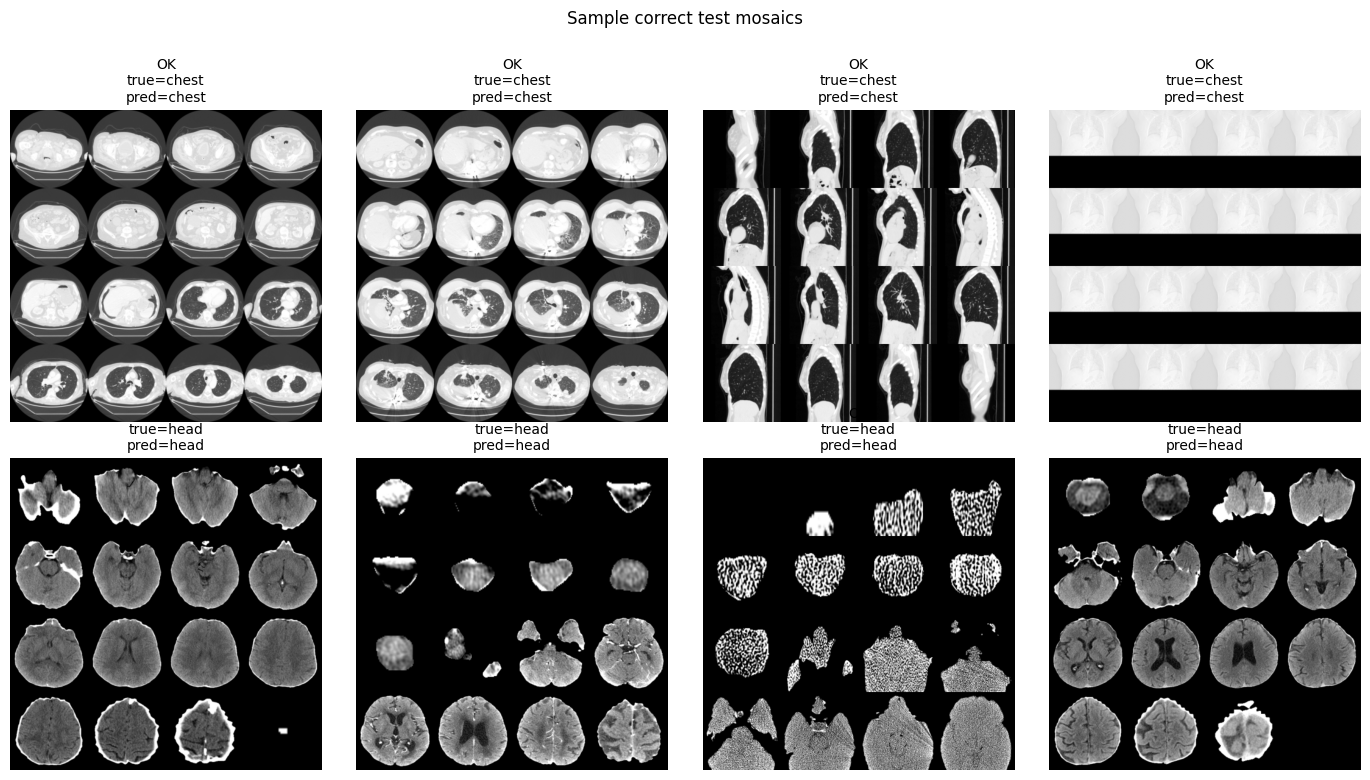

In [9]:
label_col = "true_label_name" if "true_label_name" in correct.columns else "body_region"
sample_correct = (
    correct.groupby(label_col, group_keys=False)
    .apply(lambda group: group.sample(min(len(group), 4), random_state=42))
    .reset_index(drop=True)
)
show_prediction_grid(sample_correct, title="Sample correct test mosaics")

## 9. Notes and Limitations

- Labels are metadata-derived weak labels, not radiologist-verified clinical ground truth.
- Current splits are series-level, not patient/case-level. Future evaluation should use case-level splits if case identifiers are carried into the analysis artifacts.
- Perfect or near-perfect scores on this 200-series pilot set should be treated as pipeline validation, not clinical performance.
- For future multi-class experiments, update `RESULTS_DIR` and confirm `label_mapping.json`, predictions, and metrics use the same class ordering.